In [2]:
import pandas as pd
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

def compute_top_scores(candidate: str, references: list, top_n: int = 3) -> dict:
    """
    Compute BLEU, ROUGE-1, and ROUGE-L scores between a candidate sentence and a list of reference sentences.
    Returns the top N scoring references for each metric.

    Args:
        candidate (str): The generated sentence.
        references (list): A list of reference sentences.
        top_n (int): Number of top scores to return.

    Returns:
        dict: A dictionary containing top N scores and corresponding references for BLEU, ROUGE-1, and ROUGE-L.
    """
    # Initialize smoothing function for BLEU
    smoothing = SmoothingFunction().method1

    # Initialize ROUGE scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

    # Tokenize candidate
    candidate_tokens = nltk.word_tokenize(candidate)

    # Lists to store scores
    bleu_scores = []
    rouge1_scores = []
    rougeL_scores = []

    for ref in references:
        # Tokenize reference
        ref_tokens = nltk.word_tokenize(ref)

        # Compute BLEU score
        bleu = sentence_bleu([ref_tokens], candidate_tokens, smoothing_function=smoothing)

        # Compute ROUGE scores
        rouge_scores = scorer.score(ref, candidate)
        rouge1 = rouge_scores['rouge1'].fmeasure
        rougeL = rouge_scores['rougeL'].fmeasure

        # Append scores with corresponding reference
        bleu_scores.append((bleu, ref))
        rouge1_scores.append((rouge1, ref))
        rougeL_scores.append((rougeL, ref))

    # Sort scores in descending order and get top N
    top_bleu = sorted(bleu_scores, key=lambda x: x[0], reverse=True)[:top_n]
    top_rouge1 = sorted(rouge1_scores, key=lambda x: x[0], reverse=True)[:top_n]
    top_rougeL = sorted(rougeL_scores, key=lambda x: x[0], reverse=True)[:top_n]

    return {
        'top_bleu': top_bleu,
        'top_rouge1': top_rouge1,
        'top_rougeL': top_rougeL
    }


gen_models = ["google/gemma-3-12b-it", "google/gemma-3-1b-it", "mistral.mistral-7b-instruct-v0:2"]
agg_funcs = {
    'base_found_rag_match': ['sum', lambda x: (~x).sum()],  # sum of Trues, sum of Falses
    'base_found_match': ['sum', lambda x: (~x).sum()],
    'fk_score': ['mean', 'var'],
    'dc_score': ['mean', 'var'],
    'root_similarity_score': ['mean', 'var'],
}
# Define base colors for models
model_colors = {
    'google/gemma-3-1b-it': 'green',
    'google/gemma-3-12b-it': 'blue',
    'mistral.mistral-7b-instruct-v0:2': 'red',
}

[nltk_data] Downloading package punkt to /homes/lst20/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
from analysis.utils import read_trees_to_df

dfs_para_ = []

for model in gen_models:
    try:
        df = read_trees_to_df("paraphrase_then_prefix", model)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_para_.append(df)
    except KeyError as e:
        print(e)

dfs_paraprefix_ = pd.concat(dfs_para_, ignore_index=True)
df_perplexity = pd.read_csv("/homes/lst20/fyp/fyp_resources/LexEval-main/analysis/df_paraprefix_.csv", usecols=["perplexity"])
dfs_paraprefix_["perplexity"] = df_perplexity["perplexity"].values
dfs_paraprefix_.columns


tree count: 127
google/gemma-3-12b-it df len: 1810
tree count: 127
google/gemma-3-1b-it df len: 1810
tree count: 127
mistral.mistral-7b-instruct-v0:2 df len: 1810


Index(['gen_modelId', 'question_id', 'layer', 'id', 'type', 'prompt',
       'rag_closest_match', 'rag_entities', 'possible_answers', 'metadata',
       'wiki_title', 'base_found_rag_match', 'base_found_match',
       'root_similarity_score', 'complexity_score', 'fk_score', 'dc_score',
       'similarity', 'base', 'base_rag', 'perplexity'],
      dtype='object')

In [ ]:
# Apply scoring
def get_context(tp_list):
    return list(t[0]["context"] for t in tp_list)
dfs_paraprefix_['scores'] = dfs_paraprefix_.apply(
    lambda row: compute_top_scores(
        row['base_rag'],
        get_context(row['rag_closest_match'][1:])    # ← everything but the first item
    ),
    axis=1
)
# Extract top scores and references
dfs_paraprefix_['top_bleu'] = dfs_paraprefix_['scores'].apply(lambda x: x['top_bleu'])
dfs_paraprefix_['top_rouge1'] = dfs_paraprefix_['scores'].apply(lambda x: x['top_rouge1'])
dfs_paraprefix_['top_rougeL'] = dfs_paraprefix_['scores'].apply(lambda x: x['top_rougeL'])

In [ ]:
import numpy as np

dfs_paraprefix_["top_bleu"] = dfs_paraprefix_["top_bleu"].apply(
    lambda x: np.log10(x[0][0] + 1e-200)
              if isinstance(x, list) and len(x) and len(x[0]) 
              else np.nan
)

# and similarly…
dfs_paraprefix_["top_rouge1"] = dfs_paraprefix_["top_rouge1"].apply(
    lambda x: np.log10(x[0][0] + 1e-200)
              if isinstance(x, list) and len(x) and len(x[0]) 
              else np.nan
)
dfs_paraprefix_["top_rougeL"] = dfs_paraprefix_["top_rougeL"].apply(
    lambda x: np.log10(x[0][0] + 1e-200)
              if isinstance(x, list) and len(x) and len(x[0]) 
              else np.nan
)

In [ ]:
dfs_paraprefix_.drop(columns=["scores"], inplace=True)

dfs_paraprefix_.to_csv("df_paraprefix_scores.csv", index=False)

In [ ]:
import pandas as pd

def compute_accuracy_correlation(df_) -> pd.DataFrame:
    df = df_.copy()
    sub = df[['fk_score', 'perplexity', 'similarity', 'dc_score', 'base_found_rag_match', 'base_found_match', 'top_bleu', 'top_rouge1', 'top_rougeL']].copy()
    
    # Convert booleans to int (True→1, False→0)
    sub['base_found_rag_match'] = sub['base_found_rag_match'].astype(int)
    sub['base_found_match'] = sub['base_found_match'].astype(int)
    
    # Compute and return correlation matrix
    return sub.corr()

def corr_scores_when_root_true(df_):
    df = df_.copy()
    # 1) Filter to only RootNode rows where base_found_rag_match is True
    mask = (df['type'] == 'RootNode') & (df['base_found_rag_match'] == True)
    print("RootNode & RAG-matched rows:", df[mask].shape)

    # 2) Grab the unique question IDs from that slice
    qids = df.loc[mask, 'question_id'].unique()

    # 3) Now build a mask to select *all* rows whose questionid is in that list
    mask_qid = df['question_id'].isin(qids)

    sub = df.loc[mask_qid, ['fk_score', 'perplexity', 'similarity', 'dc_score', 'base_found_rag_match', 'base_found_match', 'top_bleu', 'top_rouge1', 'top_rougeL']].copy()

    # 2) Cast the booleans to ints
    sub['base_found_rag_match'] = sub['base_found_rag_match'].astype(int)
    sub['base_found_match'] = sub['base_found_match'].astype(int)

    # 3) Compute the 4×4 Pearson correlation matrix
    corr_scores_when_root_true = sub.corr()
    return corr_scores_when_root_true
   


In [ ]:
corr_matrix = compute_accuracy_correlation(dfs_paraprefix_)
root_true_corr = corr_scores_when_root_true(dfs_paraprefix_)


RootNode & RAG-matched rows: (257, 24)


In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracy_correlation(df, **kwargs):
    """
    Compute and plot the correlation matrix for FK, perplexity, and accuracy.
    Pass the same kwargs as compute_accuracy_correlation, e.g. column names.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(df, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation Matrix: FK, Perplexity, RAG/Base Accuracy")
    plt.tight_layout()
    plt.show()

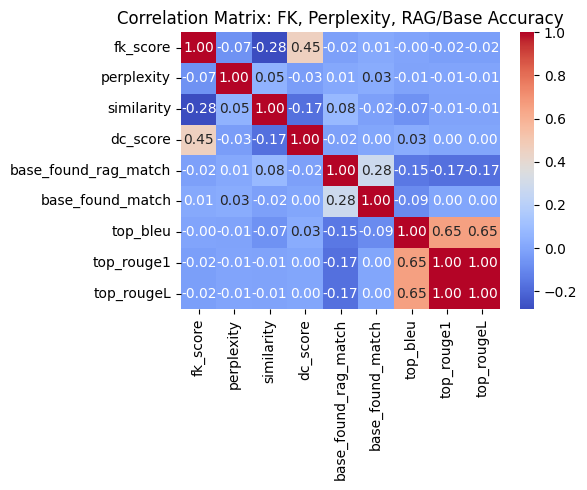

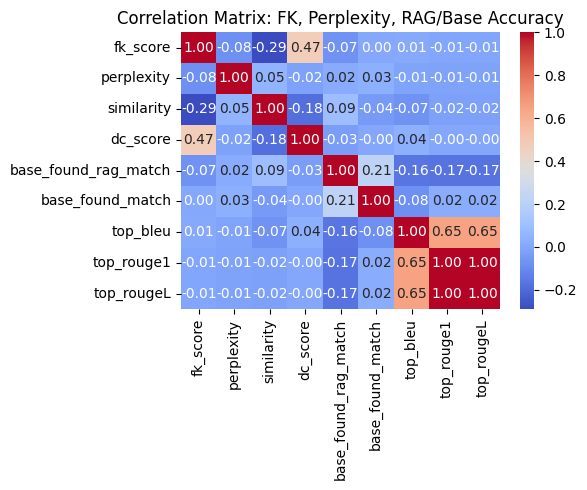

In [95]:
plot_accuracy_correlation(corr_matrix)
plot_accuracy_correlation(root_true_corr)